In [18]:
EXPERIMENT = "pattern"
SAVE_FIGURES = False


# Imports


In [19]:
import jax
import jax.numpy as np
import equinox as eqx

jax.config.update("jax_enable_x64", True)

import jax_morph as jxm  # type: ignore

key = jax.random.PRNGKey(0)

import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 22})

from tqdm import tqdm

import os

os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".95"


In [20]:
if SAVE_FIGURES:
    # create the figures subdirectory if it doesn't exist
    os.makedirs("figures", exist_ok=True)


# Pattern Forward Model

This copy runs the three-cell-type pattern adhesion model: salt-and-pepper with shell.


In [21]:
from pathlib import Path
import importlib
import importlib.util
import json
from collections import namedtuple

NOTEBOOK_DIR = Path.cwd()

import pattern_istate_and_model as pattern_model

importlib.reload(pattern_model)

from IPython.display import Image as DisplayImage, display
import numpy as onp


In [22]:
FORWARD_OUTDIR = NOTEBOOK_DIR / "pattern_forward_outputs"
FORWARD_OUTDIR.mkdir(exist_ok=True)

PATTERN = "salt-pepper-shell"
# J = np.array([3.8,3.8,0.9,3.8,0.9,0.8])  # [J11, J12, J13, J22, J23, J33]
# envelop + s&p
# J = np.array([3.2530967418684433, 2.973676847732232, 1.17428125590103, 3.1452662449814284, 1.2830031759728924, 1.8517135350777736])
J=np.array([3.63, 3.62, 1.12, 3.30, 1.08, 1.32])
N_CELLS = 90
TYPE_RATIOS = np.array([1,1,6])  # [type1, type2, type3]
# envelop + s&p
# TYPE_RATIOS = np.array([3,3,54])
# TYPE_RATIOS = np.array([24,26,10])
HIDE_TYPES = [3]  # one-based cell types to hide, e.g. [3] hides type 3
N_STEPS = 50
SEED = 0

key = jax.random.PRNGKey(SEED)
key, init_key, sim_key = jax.random.split(key, 3)

istate_pattern = pattern_model.build_istate(init_key, n_cells=N_CELLS, type_ratios=TYPE_RATIOS)
model_pattern = pattern_model.build_model(J, initial_type_fractions=TYPE_RATIOS / TYPE_RATIOS.sum())
trajectory_pattern = jxm.simulate(model_pattern, istate_pattern, sim_key, N_STEPS, history=True)
if isinstance(trajectory_pattern, tuple):
    trajectory_pattern = trajectory_pattern[0]
fstate_pattern = jax.tree_util.tree_map(lambda x: x[-1], trajectory_pattern)

initial_loss = float(pattern_model.pattern_loss(istate_pattern, pattern=PATTERN))
loss = float(pattern_model.pattern_loss(fstate_pattern, pattern=PATTERN))
print(f"Initial loss: {initial_loss:.3f}")
print(f"Final loss: {loss:.3f}")


Initial loss: -1.117
Final loss: -2.121


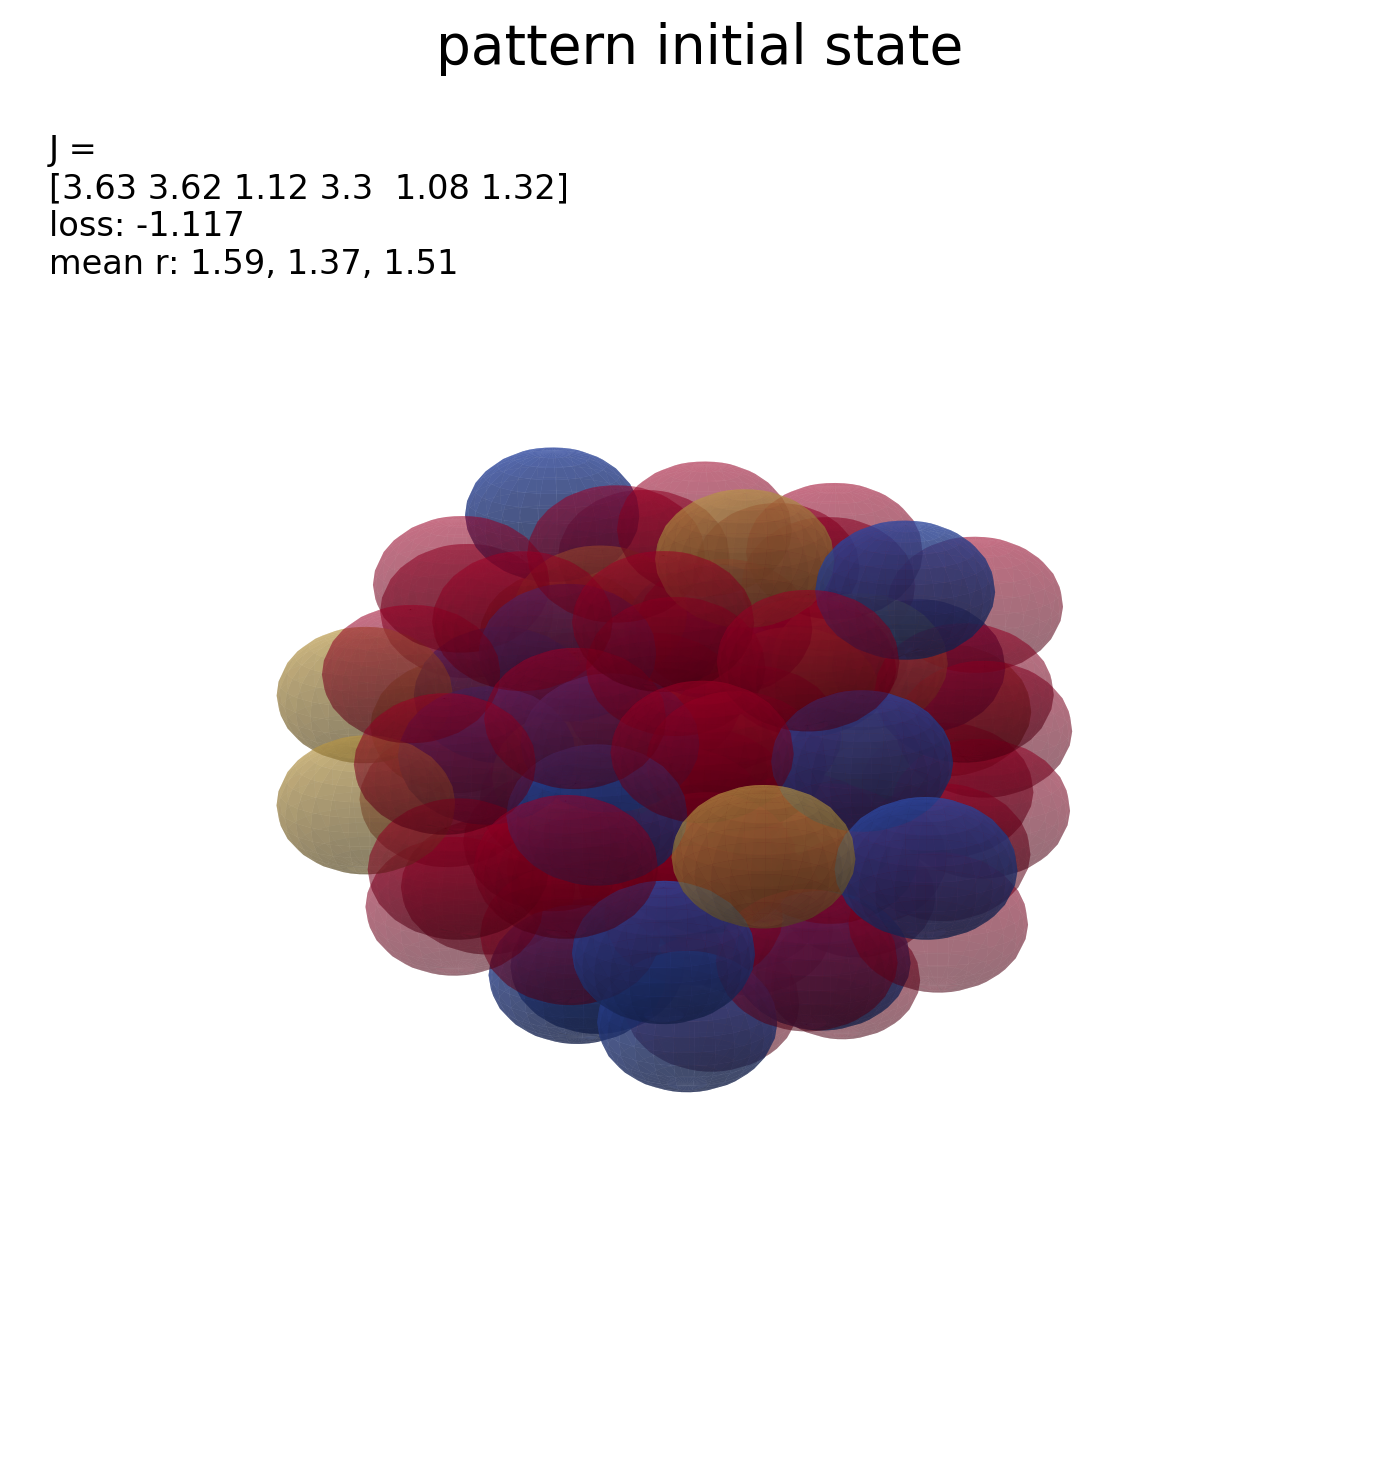

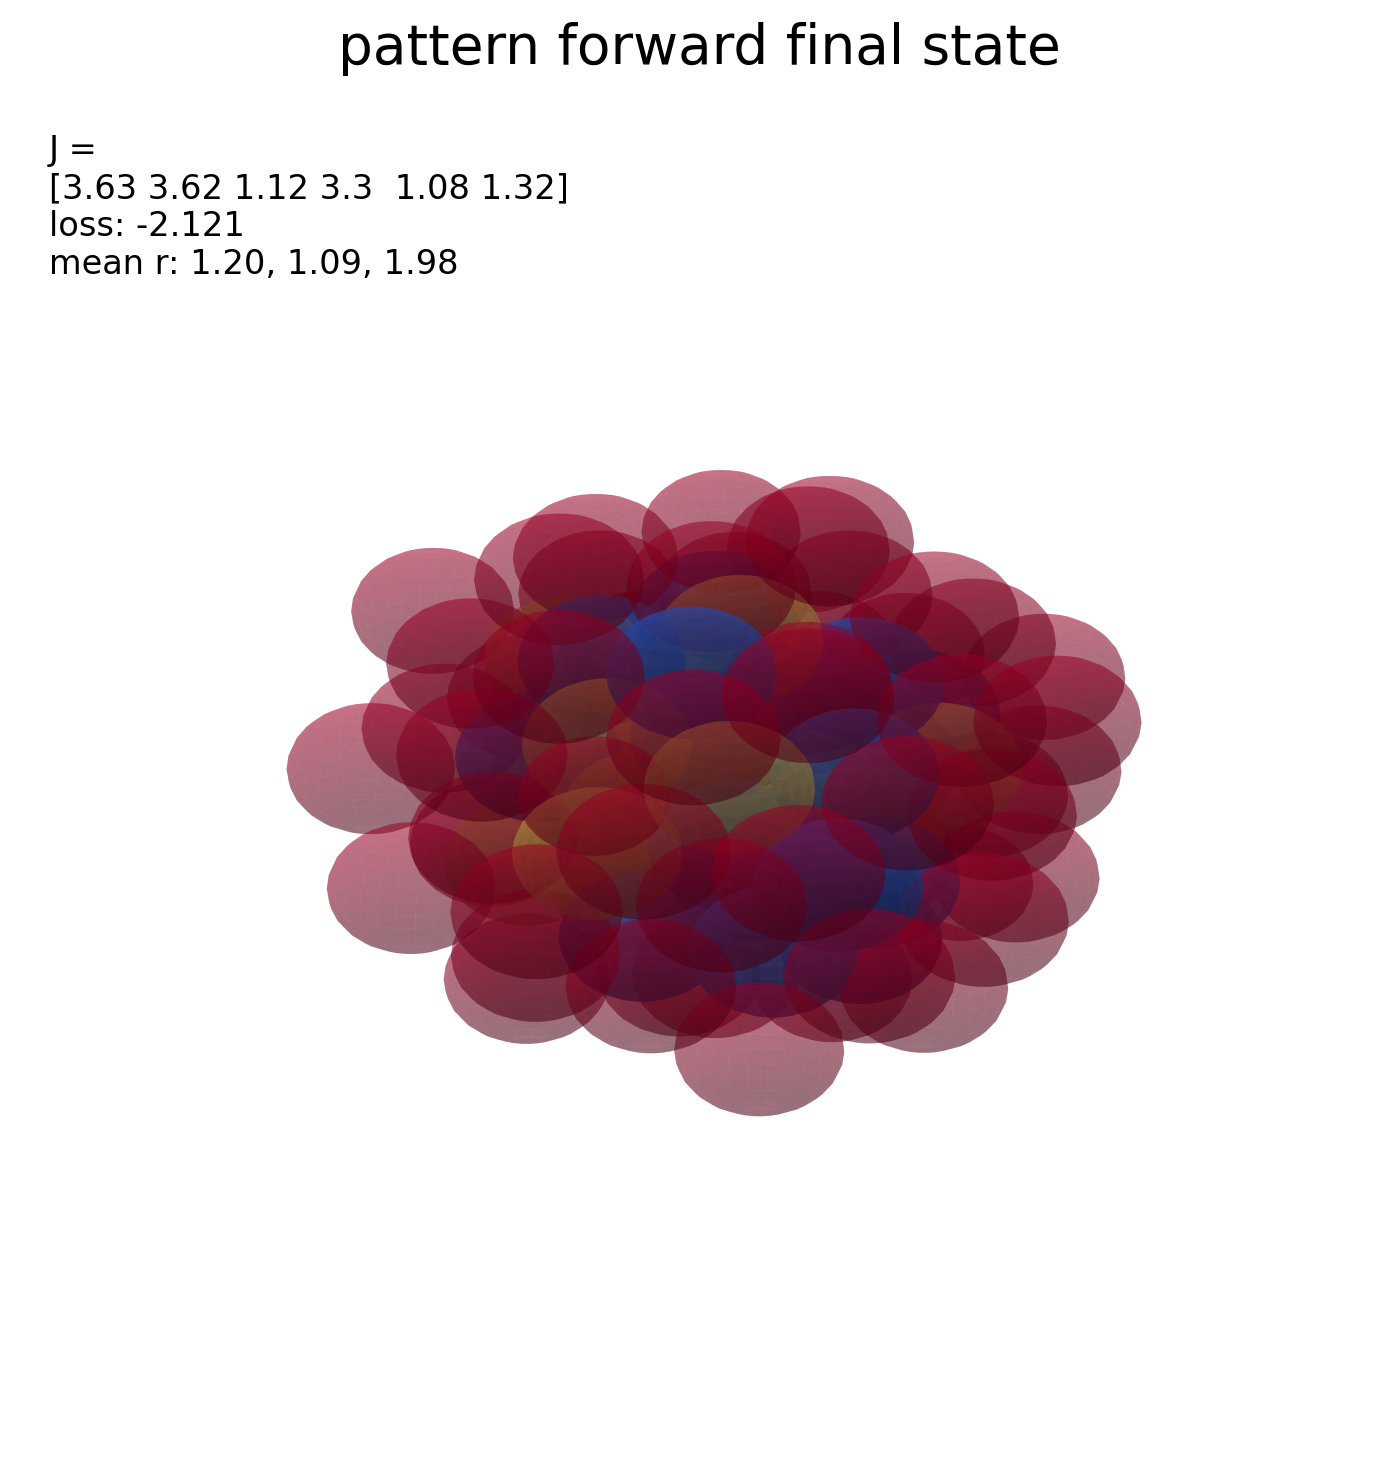

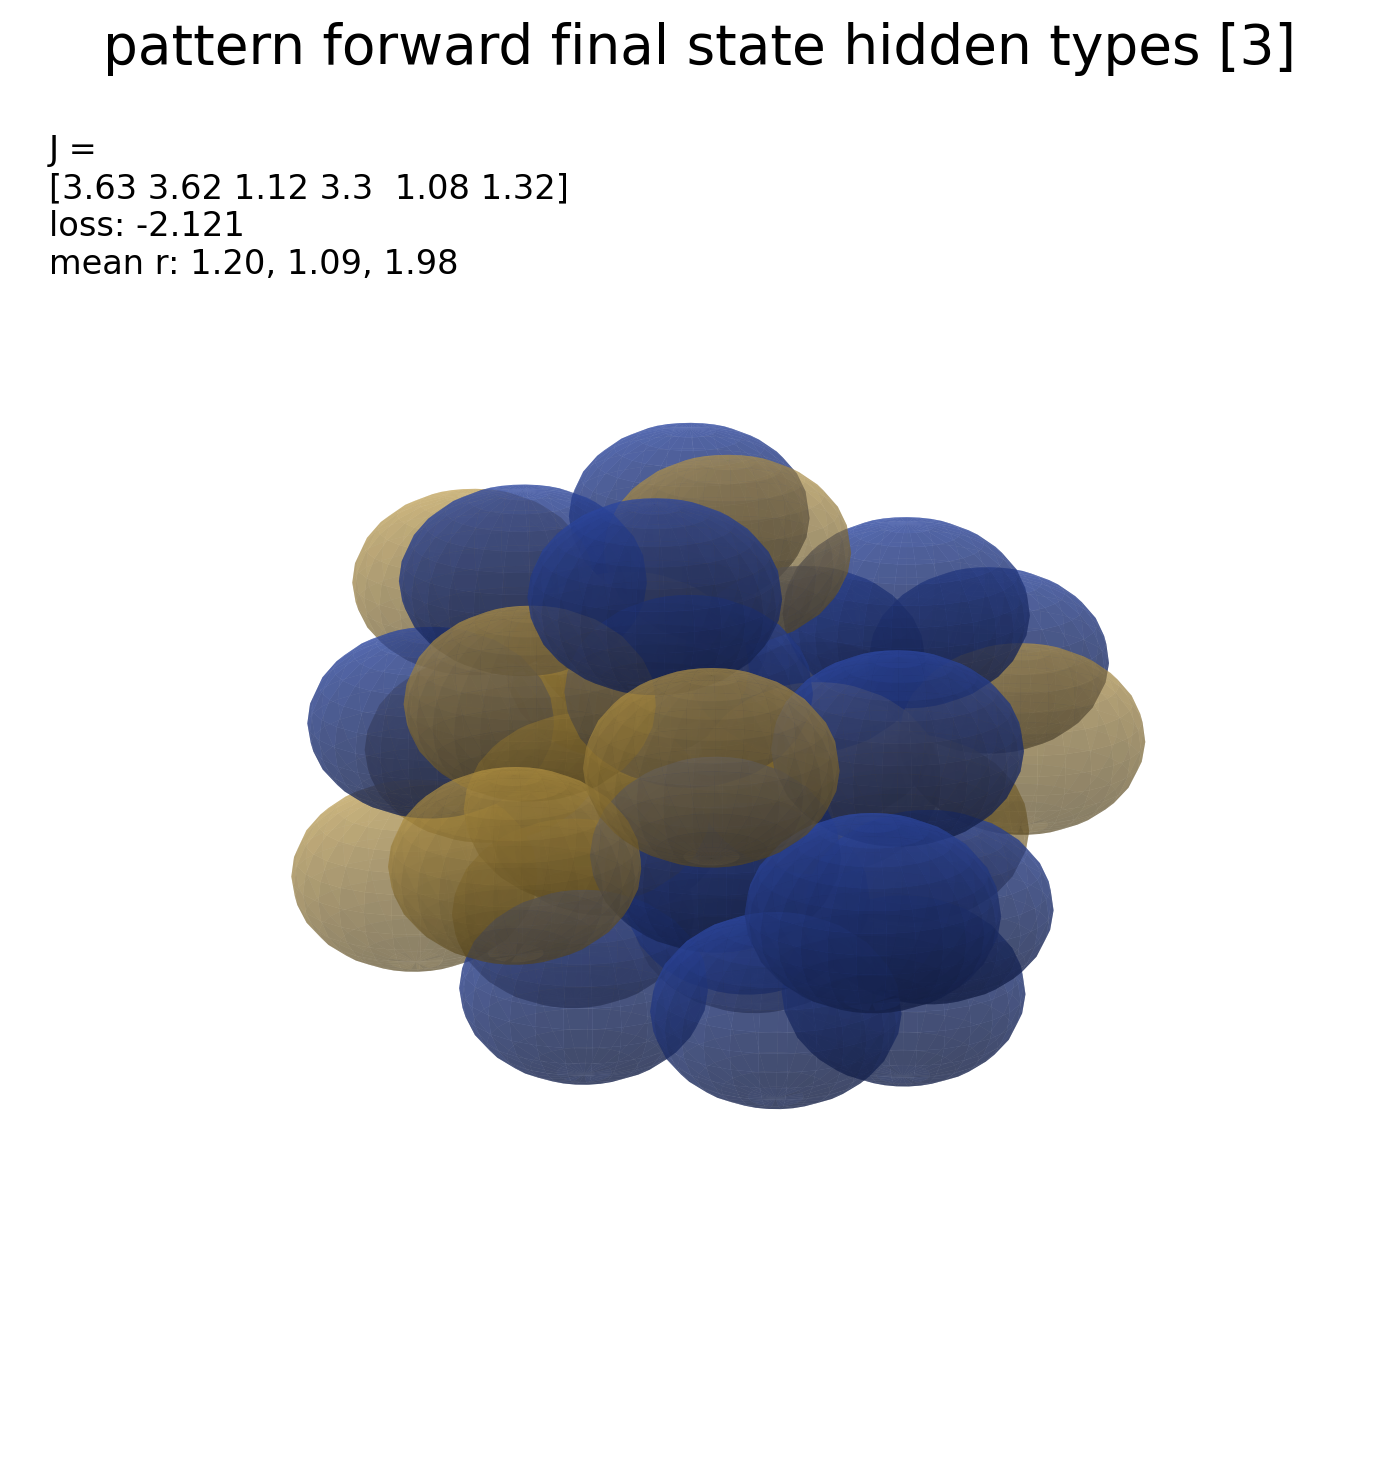

In [23]:
def _load_translucent_sphere_plotter(notebook_dir):
    plot_path = Path(notebook_dir) / "translucent-3d-plotting.py"
    spec = importlib.util.spec_from_file_location("translucent_3d_plotting", plot_path)
    sphere_plotting = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(sphere_plotting)
    return sphere_plotting.plot_translucent_spheres


def pattern_metrics(state, *, pattern, **loss_kwargs):
    positions = onp.asarray(state.position)
    type_idx = onp.asarray(onp.argmax(state.celltype, axis=1))
    metrics = {"loss": float(pattern_model.pattern_loss(state, pattern=pattern, **loss_kwargs))}
    for i in range(3):
        mask = type_idx == i
        if onp.any(mask):
            type_positions = positions[mask]
            type_center = type_positions.mean(axis=0)
            dist = onp.sqrt(onp.sum((type_positions - type_center) ** 2, axis=-1) + 1e-8)
            metrics[f"mean_radius_type_{i + 1}"] = float(onp.mean(dist))
        else:
            metrics[f"mean_radius_type_{i + 1}"] = 0.0
        metrics[f"count_type_{i + 1}"] = int(onp.sum(mask))
    return metrics


def visible_cell_mask(state, hidden_types=None):
    hidden_types = set(hidden_types or [])
    if not hidden_types:
        return None
    type_idx = onp.asarray(onp.argmax(state.celltype, axis=1)) + 1
    return ~onp.isin(type_idx, list(hidden_types))


def hidden_filename(filename, hidden_types):
    path = Path(filename)
    hidden_tag = "-hidden-" + "-".join(str(t) for t in hidden_types)
    return f"{path.stem}{hidden_tag}{path.suffix}"


def save_pattern_state_visualization(*, outdir, state, title, filename, target_j, pattern, hidden_types=None, **loss_kwargs):
    outdir = Path(outdir)
    outdir.mkdir(exist_ok=True)
    path = outdir / filename
    hidden_types = list(hidden_types or [])
    plot_translucent_spheres = _load_translucent_sphere_plotter(NOTEBOOK_DIR)
    metrics = pattern_metrics(state, pattern=pattern, **loss_kwargs)

    plot_translucent_spheres(state, path, title, metrics, target_j)
    result = {"path": str(path), "hidden_path": None, "metrics": metrics}

    if hidden_types:
        hidden_path = outdir / hidden_filename(filename, hidden_types)
        cell_mask = visible_cell_mask(state, hidden_types)
        hidden_title = f"{title} hidden types {hidden_types}"
        plot_translucent_spheres(state, hidden_path, hidden_title, metrics, target_j, cell_mask=cell_mask)
        result["hidden_path"] = str(hidden_path)

    return result


def display_preview(preview, width=420):
    display(DisplayImage(filename=preview["path"], width=width))
    if preview.get("hidden_path") is not None:
        display(DisplayImage(filename=preview["hidden_path"], width=width))


initial_preview = save_pattern_state_visualization(
    outdir=FORWARD_OUTDIR,
    state=istate_pattern,
    title="pattern initial state",
    filename="pattern-initial-state.png",
    target_j=J,
    pattern=PATTERN,
)

final_preview = save_pattern_state_visualization(
    outdir=FORWARD_OUTDIR,
    state=fstate_pattern,
    title="pattern forward final state",
    filename="pattern-forward-final-state.png",
    target_j=J,
    pattern=PATTERN,
    hidden_types=HIDE_TYPES,
)

display_preview(initial_preview, width=420)
display_preview(final_preview, width=420)


In [24]:
# animation_outputs = forward_viz.save_forward_animation(
#     outdir=FORWARD_OUTDIR,
#     istate=istate_pattern,
#     trajectory=trajectory_pattern,
# )

# animation_outputs["animation"]


# Core Cross-Contact Null Test

This section tests whether type 1/type 2 core contacts are more or less mixed than expected from random labels on the same final geometry. For each simulated final state, it keeps the core contact matrix fixed, shuffles only the type 1/type 2 labels `NULL_SAMPLES` times, and compares the observed cross-contact ratio to that state-specific null distribution.


In [ ]:
CROSS_CONTACT_OUTDIR = NOTEBOOK_DIR / "pattern_cross_contact_null_outputs"
CROSS_CONTACT_OUTDIR.mkdir(exist_ok=True)

# Pass the visible J matrix to simulate here: [J11, J12, J13, J22, J23, J33].
CROSS_CONTACT_J = [1,1,1,1,1,1]
CROSS_CONTACT_N_SIMULATIONS = 300
NULL_SAMPLES = 1000
CROSS_CONTACT_SEED = 0

# Keep None for the same smooth contact weights used by pattern_loss.
# Set to a value like 0.5 if you want hard contacts instead.
CONTACT_THRESHOLD = None


In [26]:
def contact_ratio_from_model_helpers(state, contact):
    cross_12 = float(pattern_model.contact_frequency_from_contact(state, contact, 0, 1))
    self_11 = float(pattern_model.contact_frequency_from_contact(state, contact, 0, 0))
    self_22 = float(pattern_model.contact_frequency_from_contact(state, contact, 1, 1))
    
    return cross_12 / (cross_12 + self_11 + self_22) 


def state_with_shuffled_core_labels(state, rng):
    # Convert one-hot labels to integer labels so only type 1/type 2 labels can be shuffled.
    labels = onp.asarray(onp.argmax(state.celltype, axis=1))
    core_mask = labels < 2

    # Keep cell positions and type-3 shell labels fixed; shuffle only labels in the core.
    shuffled_labels = labels.copy()
    shuffled_labels[core_mask] = rng.permutation(shuffled_labels[core_mask])

    # Convert back to one-hot labels and place them into an otherwise unchanged state.
    shuffled_celltype = jax.nn.one_hot(np.asarray(shuffled_labels), state.celltype.shape[1])
    return eqx.tree_at(lambda s: s.celltype, state, shuffled_celltype)


def null_cross_contact_ratios(state, contact, *, n_samples=1000, seed=0):
    # A fixed seed makes the shuffle null exactly reproducible.
    rng = onp.random.default_rng(int(seed))
    ratios = onp.empty(int(n_samples), dtype=float)
    for sample_i in range(int(n_samples)):
        shuffled_state = state_with_shuffled_core_labels(state, rng)
        ratios[sample_i] = contact_ratio_from_model_helpers(shuffled_state, contact)
    return ratios


def compare_state_to_cross_contact_null(state, *, n_samples=1000, seed=0, contact_threshold=None):
    # Keep the geometry/contact matrix fixed for the observed state and every label shuffle.
    contact = pattern_model._contact_matrix(state)
    if contact_threshold is not None:
        contact = (contact >= float(contact_threshold)).astype(contact.dtype)

    observed = contact_ratio_from_model_helpers(state, contact)
    null = null_cross_contact_ratios(state, contact, n_samples=n_samples, seed=seed)
    null_mean = float(onp.nanmean(null))
    null_std = float(onp.nanstd(null, ddof=1))

    # Z-score says how many null standard deviations the observed ratio is from random label mixing.
    z_score = float((observed - null_mean) / null_std) if null_std > 0 else onp.nan
    labels = onp.asarray(onp.argmax(state.celltype, axis=1))
    return {
        "observed": float(observed),
        "null": null,
        "null_mean": null_mean,
        "null_std": null_std,
        "z_score": z_score,
        "n_core_type_1": int(onp.sum(labels == 0)),
        "n_core_type_2": int(onp.sum(labels == 1)),
    }


In [ ]:
def simulate_final_states_for_j(
    visible_j,
    *,
    n_simulations=30,
    n_cells=N_CELLS,
    type_ratios=TYPE_RATIOS,
    n_steps=N_STEPS,
    seed=0,
):
    """Run replicate simulations from the same visible J matrix."""
    visible_j = np.asarray(visible_j)
    model = pattern_model.build_model(visible_j, initial_type_fractions=type_ratios / type_ratios.sum())
    master_key = jax.random.PRNGKey(int(seed))
    final_states = []
    seeds = []
    for sim_i in tqdm(range(int(n_simulations)), desc="simulate J replicates"):
        master_key, init_key, sim_key = jax.random.split(master_key, 3)
        istate_i = pattern_model.build_istate(init_key, n_cells=n_cells, type_ratios=type_ratios)
        result = jxm.simulate(model, istate_i, sim_key, int(n_steps))
        final_states.append(result[0] if isinstance(result, tuple) else result)
        seeds.append(int(jax.random.randint(jax.random.fold_in(master_key, sim_i), (), 0, 2**31 - 1)))
    return final_states, seeds


def run_cross_contact_null_experiment(
    visible_j,
    *,
    n_simulations=30,
    null_samples=1000,
    seed=0,
    contact_threshold=None,
):
    final_states, sim_seeds = simulate_final_states_for_j(
        visible_j,
        n_simulations=n_simulations,
        seed=seed,
    )
    rows = []
    null_by_sim = []
    for sim_i, state in enumerate(tqdm(final_states, desc="shuffle null labels")):
        # Use a different deterministic shuffle seed for each simulation.
        result = compare_state_to_cross_contact_null(
            state,
            n_samples=null_samples,
            seed=seed + 100_000 + sim_i,
            contact_threshold=contact_threshold,
        )
        null_by_sim.append(result.pop("null"))
        rows.append({
            "simulation": sim_i,
            "seed": sim_seeds[sim_i],
            **result,
        })
    return rows, null_by_sim, final_states


cross_contact_rows, cross_contact_nulls, cross_contact_final_states = run_cross_contact_null_experiment(
    CROSS_CONTACT_J,
    n_simulations=CROSS_CONTACT_N_SIMULATIONS,
    null_samples=NULL_SAMPLES,
    seed=CROSS_CONTACT_SEED,
    contact_threshold=CONTACT_THRESHOLD,
)

for row in cross_contact_rows[:5]:
    print(
        f"sim {row['simulation']:02d}: observed={row['observed']:.3f}, "
        f"null={row['null_mean']:.3f}+/-{row['null_std']:.3f}, "
        f"z={row['z_score']:.2f}"
    )


shuffle null labels: 100%|██████████| 30/30 [00:31<00:00,  1.06s/it]

sim 00: observed=0.370, null=0.335+/-0.050, z=0.70
sim 01: observed=0.312, null=0.335+/-0.052, z=-0.45
sim 02: observed=0.448, null=0.335+/-0.055, z=2.07
sim 03: observed=0.378, null=0.336+/-0.044, z=0.95
sim 04: observed=0.388, null=0.338+/-0.049, z=1.03


saved /Users/mw/Desktop/jax-morph/results-natcompsci-2025/concentric-ring-my-own/pattern_cross_contact_null_outputs/cross_contact_null_summary.png


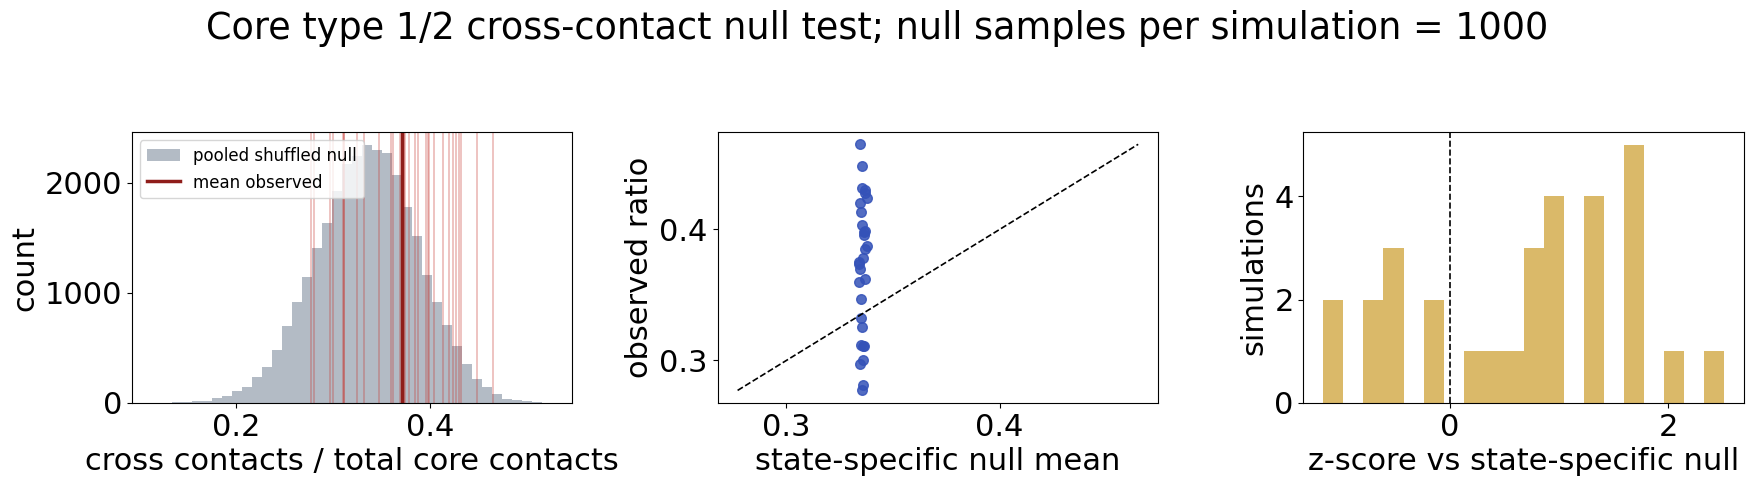

In [28]:
observed = onp.asarray([row["observed"] for row in cross_contact_rows], dtype=float)
null_mean = onp.asarray([row["null_mean"] for row in cross_contact_rows], dtype=float)
z_scores = onp.asarray([row["z_score"] for row in cross_contact_rows], dtype=float)
pooled_null = onp.concatenate(cross_contact_nulls)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

axes[0].hist(pooled_null, bins=40, color="#9aa4b2", alpha=0.75, label="pooled shuffled null")
for value in observed:
    axes[0].axvline(value, color="#c7352f", alpha=0.35, linewidth=1.2)
axes[0].axvline(float(onp.nanmean(observed)), color="#8f1d1a", linewidth=2.5, label="mean observed")
axes[0].set_xlabel("cross contacts / total core contacts")
axes[0].set_ylabel("count")
axes[0].legend(fontsize=12)

axes[1].scatter(null_mean, observed, color="#3452b8", s=48, alpha=0.85)
lo = float(min(onp.nanmin(null_mean), onp.nanmin(observed)))
hi = float(max(onp.nanmax(null_mean), onp.nanmax(observed)))
axes[1].plot([lo, hi], [lo, hi], color="black", linewidth=1.2, linestyle="--")
axes[1].set_xlabel("state-specific null mean")
axes[1].set_ylabel("observed ratio")

axes[2].hist(z_scores, bins=20, color="#d4ad4f", alpha=0.85)
axes[2].axvline(0.0, color="black", linewidth=1.2, linestyle="--")
axes[2].set_xlabel("z-score vs state-specific null")
axes[2].set_ylabel("simulations")

fig.suptitle(f"Core type 1/2 cross-contact null test; null samples per simulation = {NULL_SAMPLES}", y=1.04)
fig.tight_layout()

summary_path = CROSS_CONTACT_OUTDIR / "cross_contact_null_summary.png"
fig.savefig(summary_path, dpi=200, bbox_inches="tight")
print("saved", summary_path)
plt.show()


In [29]:
cross_contact_summary = {
    "visible_j": onp.asarray(CROSS_CONTACT_J).tolist(),
    "n_simulations": int(CROSS_CONTACT_N_SIMULATIONS),
    "null_samples": int(NULL_SAMPLES),
    "seed": int(CROSS_CONTACT_SEED),
    "contact_threshold": CONTACT_THRESHOLD,
    "mean_observed": float(onp.nanmean(observed)),
    "mean_null_mean": float(onp.nanmean(null_mean)),
    "mean_z_score": float(onp.nanmean(z_scores)),
    "rows": [
        {key: (float(value) if isinstance(value, (onp.floating, float)) else int(value) if isinstance(value, (onp.integer, int)) else value)
         for key, value in row.items()}
        for row in cross_contact_rows
    ],
}

summary_json_path = CROSS_CONTACT_OUTDIR / "cross_contact_null_summary.json"
with open(summary_json_path, "w") as f:
    json.dump(cross_contact_summary, f, indent=2)

print(json.dumps({k: v for k, v in cross_contact_summary.items() if k != "rows"}, indent=2))
print("saved", summary_json_path)


{
  "visible_j": [
    1,
    1,
    1,
    1,
    1,
    1
  ],
  "n_simulations": 30,
  "null_samples": 1000,
  "seed": 0,
  "contact_threshold": null,
  "mean_observed": 0.3713614885562754,
  "mean_null_mean": 0.3356860055202135,
  "mean_z_score": 0.6787557147280777
}
saved /Users/mw/Desktop/jax-morph/results-natcompsci-2025/concentric-ring-my-own/pattern_cross_contact_null_outputs/cross_contact_null_summary.json
